# BGGTDM v2 — Feature Exploration

No model training here. Pure exploration.

**Data:** `game_logs_features.csv` — 9,972 rows, WR + TE, 2022–2025  
**Goal:** Compute every candidate feature, visualize it, check signal. Decide nothing yet.

Features to explore:
- Catch rate, yards per target (efficiency angles)
- Target consistency (usage variance)
- Historical TD rate across our full data window
- Target share within team (cross-player aggregation)
- Player profile: height, experience, draft round
- Consecutive TD games (hot streak)
- Long reception as downfield usage proxy
- Home/away from game_id
- Catch rate trend vs season baseline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = Path('data')

df = pd.read_csv(DATA_DIR / 'game_logs_features.csv')
df['scored_td'] = (df['rec_tds'] > 0).astype(int)

with open(DATA_DIR / 'player_lookup.json') as f:
    player_lookup = json.load(f)

print(f'Loaded: {df.shape}')
print(df.groupby(['season', 'pos']).size().unstack())

Loaded: (9972, 36)
pos       TE    WR
season            
2022     711  1183
2023     815  1549
2024     911  1777
2025    1035  1991


---
## 1 — Baseline: what does TD rate actually look like?

Understand the target variable before exploring features.

In [2]:
print('Overall TD rate:')
print(df.groupby('pos')['scored_td'].agg(['mean', 'count', 'sum']).round(3))
print()
print('TD rate by season + pos:')
print(df.groupby(['season', 'pos'])['scored_td'].mean().round(3).unstack())
print()
print('TD rate by week + pos:')
print(df.groupby(['week', 'pos'])['scored_td'].mean().round(3).unstack().to_string())

Overall TD rate:
     mean  count   sum
pos                   
TE  0.166   3472   577
WR  0.218   6500  1416

TD rate by season + pos:
pos       TE    WR
season            
2022   0.173 0.215
2023   0.150 0.223
2024   0.151 0.233
2025   0.187 0.202

TD rate by week + pos:
pos     TE    WR
week            
1    0.116 0.207
2    0.130 0.269
3    0.138 0.209
4    0.176 0.200
5    0.187 0.211
6    0.178 0.224
7    0.150 0.193
8    0.239 0.251
9    0.227 0.198
10   0.167 0.231
11   0.125 0.199
12   0.163 0.212
13   0.134 0.246
14   0.181 0.197
15   0.170 0.223
16   0.167 0.241
17   0.196 0.207
18   0.154 0.202


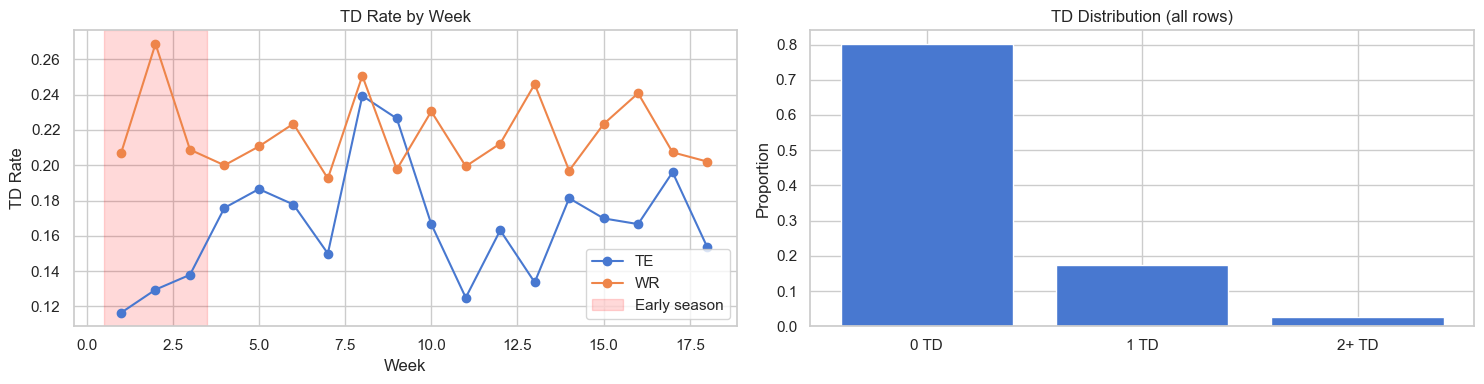

Multi-TD games: 262 (2.6% of all games)


In [3]:
# TD rate by week — WR vs TE pattern
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

td_week = df.groupby(['week', 'pos'])['scored_td'].mean().unstack()
td_week.plot(ax=axes[0], marker='o')
axes[0].axvspan(0.5, 3.5, alpha=0.15, color='red', label='Early season')
axes[0].set_title('TD Rate by Week')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('TD Rate')
axes[0].legend()

# Multi-TD games — does it happen enough to matter?
multi_td = df[df['rec_tds'] >= 2]
axes[1].bar(['0 TD', '1 TD', '2+ TD'],
            [(df['rec_tds']==0).mean(), (df['rec_tds']==1).mean(), (df['rec_tds']>=2).mean()])
axes[1].set_title('TD Distribution (all rows)')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()
print(f'Multi-TD games: {len(multi_td)} ({len(multi_td)/len(df)*100:.1f}% of all games)')

---
## 2 — Efficiency Features

`catch_rate`, `yards_per_target`, `long_rec` as downfield usage proxy

In [4]:
df = df.sort_values(['player_id', 'season', 'week']).reset_index(drop=True)
grp = df.groupby(['player_id', 'season'])

# --- Catch rate (receptions / targets) ---
# Raw per-game
df['catch_rate_raw'] = np.where(df['targets'] > 0, df['receptions'] / df['targets'], np.nan)

# Lagged (previous game catch rate)
df['lag_catch_rate'] = grp['catch_rate_raw'].shift(1)

# Rolling 3-game catch rate
df['roll3_catch_rate'] = (
    grp['receptions'].transform(lambda x: x.rolling(3, min_periods=1).sum()) /
    grp['targets'].transform(lambda x: x.rolling(3, min_periods=1).sum()).clip(lower=1)
).shift(1)  # shift so no leakage

# Season catch rate (cumulative)
df['season_catch_rate'] = (
    df['cum_receptions'] / df['cum_targets'].clip(lower=1)
)

# --- Yards per target ---
df['lag_ypt'] = np.where(
    grp['targets'].shift(1) > 0,
    grp['rec_yards'].shift(1) / grp['targets'].shift(1),
    np.nan
)
df['season_ypt'] = df['cum_yards'] / df['cum_targets'].clip(lower=1)

# --- Long reception (downfield usage) ---
# Rolling avg long reception — bigger = used as vertical threat
df['roll3_long_rec'] = (
    grp['long_rec']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
    .shift(1)
)

print('Efficiency features added')
df[['pos', 'catch_rate_raw', 'lag_catch_rate', 'roll3_catch_rate', 'lag_ypt', 'season_ypt', 'roll3_long_rec']].describe().round(3)

Efficiency features added


,catch_rate_raw,lag_catch_rate,roll3_catch_rate,lag_ypt,season_ypt,roll3_long_rec
count,9970.000,9004.000,9971.000,9004.000,9971.000,9971.000
mean,0.656,0.655,0.657,7.736,7.660,17.284
std,0.305,0.301,0.197,6.166,3.374,9.995
min,0.000,0.000,0.000,-9.000,-5.000,-5.000
25%,0.500,0.500,0.545,4.000,6.000,10.000
50%,0.667,0.667,0.667,6.889,7.521,16.000
75%,1.000,1.000,0.778,10.364,9.033,23.000
max,1.000,1.000,1.000,86.000,69.000,81.000


In [5]:
# Correlation with TD — in-season rows only (games_played >= 1)
eff_feats = ['lag_catch_rate', 'roll3_catch_rate', 'season_catch_rate', 'lag_ypt', 'season_ypt', 'roll3_long_rec']
in_season = df[df['games_played'] >= 1].copy()

corr_eff = in_season[eff_feats + ['scored_td']].corr()['scored_td'].drop('scored_td').sort_values(ascending=False)
print('Efficiency feature correlations with TD:')
print(corr_eff.round(3))

Efficiency feature correlations with TD:
roll3_long_rec      0.143
season_ypt          0.041
lag_ypt             0.034
lag_catch_rate      0.006
roll3_catch_rate    0.006
season_catch_rate   0.005
Name: scored_td, dtype: float64


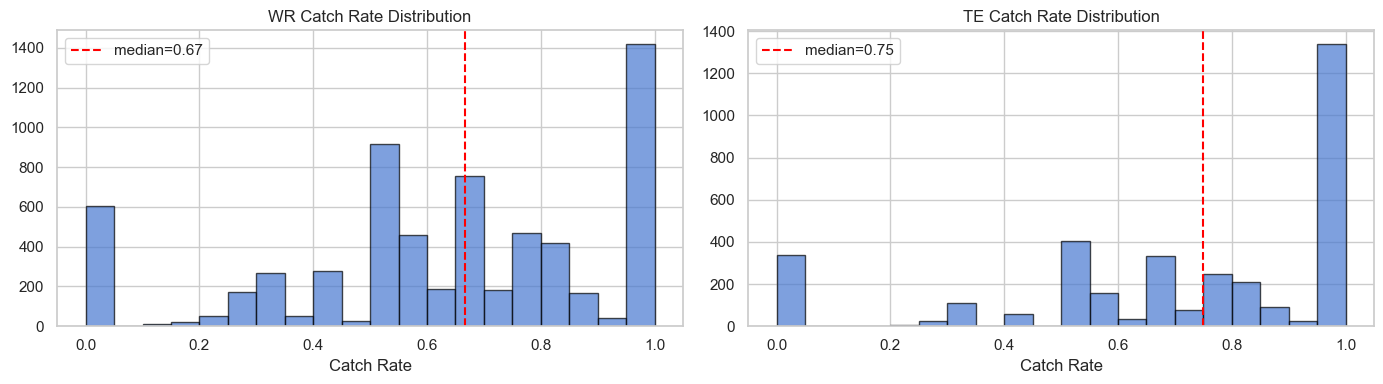

Catch rate quartile TD rates:
cr_q
Q1 (low)    0.175
Q2          0.218
Q3          0.230
Q4 (high)   0.178
Name: scored_td, dtype: float64


In [6]:
# Catch rate by position — WRs vs TEs have different profiles
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, pos in zip(axes, ['WR', 'TE']):
    sub = df[(df['pos'] == pos) & df['catch_rate_raw'].notna()]
    ax.hist(sub['catch_rate_raw'], bins=20, alpha=0.7, edgecolor='black')
    ax.axvline(sub['catch_rate_raw'].median(), color='red', linestyle='--', label=f'median={sub["catch_rate_raw"].median():.2f}')
    ax.set_title(f'{pos} Catch Rate Distribution')
    ax.set_xlabel('Catch Rate')
    ax.legend()

plt.tight_layout()
plt.show()

# Catch rate vs TD rate
print('Catch rate quartile TD rates:')
df['cr_q'] = pd.qcut(df['roll3_catch_rate'].clip(0, 1), q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
print(df.groupby('cr_q')['scored_td'].mean().round(3))

---
## 3 — Target Consistency (Usage Variance)

Is the player a reliable volume getter or wildly inconsistent?

In [7]:
# Rolling std dev of targets (3-game window, lagged)
df['roll3_target_std'] = (
    grp['targets']
    .transform(lambda x: x.rolling(3, min_periods=2).std())
    .shift(1)
)

# Coefficient of variation (std / mean) — normalized inconsistency
df['target_cv'] = df['roll3_target_std'] / df['roll3_targets'].clip(lower=0.1)

# Season target std
df['season_target_std'] = (
    grp['targets']
    .transform(lambda x: x.expanding().std())
    .shift(1)
)

in_season = df[df['games_played'] >= 2].copy()  # need >=2 for std

corr_cons = in_season[['roll3_target_std', 'target_cv', 'season_target_std', 'scored_td']].corr()['scored_td'].drop('scored_td')
print('Target consistency correlations with TD:')
print(corr_cons.round(3))
print()

# Does high consistency (low std) predict TDs more?
print('Target std quartiles vs TD rate:')
q = in_season.copy()
q['std_q'] = pd.qcut(q['roll3_target_std'].fillna(0), q=4, labels=['Q1 (consistent)', 'Q2', 'Q3', 'Q4 (volatile)'], duplicates='drop')
print(q.groupby('std_q')['scored_td'].mean().round(3))

Target consistency correlations with TD:
roll3_target_std     0.141
target_cv           -0.023
season_target_std    0.164
Name: scored_td, dtype: float64

Target std quartiles vs TD rate:
std_q
Q1 (consistent)   0.135
Q2                0.189
Q3                0.214
Q4 (volatile)     0.294
Name: scored_td, dtype: float64


---
## 4 — Streak Features

Consecutive TD games, recent scoring form

In [8]:
# Consecutive games WITH a TD (hot streak)
def consecutive_td_games(series):
    """Count of consecutive prior games with a TD (streak coming in)."""
    result = []
    streak = 0
    for val in series:
        result.append(streak)
        if val > 0:
            streak += 1
        else:
            streak = 0
    return pd.Series(result, index=series.index)

df['td_streak'] = grp['rec_tds'].transform(consecutive_td_games)

# Scored TD in each of last N games (binary flags)
df['td_last1'] = grp['rec_tds'].shift(1).gt(0).astype(float)
df['td_last2'] = grp['rec_tds'].shift(2).gt(0).astype(float)
df['td_last3'] = grp['rec_tds'].shift(3).gt(0).astype(float)

# TDs in last 3 games (count)
df['tds_last3'] = (
    grp['rec_tds']
    .transform(lambda x: x.rolling(3, min_periods=1).sum())
    .shift(1)
)

in_season = df[df['games_played'] >= 1].copy()

streak_feats = ['td_streak', 'td_last1', 'tds_last3', 'weeks_since_td']
corr_streak = in_season[streak_feats + ['scored_td']].corr()['scored_td'].drop('scored_td').sort_values(ascending=False)
print('Streak feature correlations with TD:')
print(corr_streak.round(3))

Streak feature correlations with TD:
tds_last3         0.132
td_streak         0.091
td_last1          0.084
weeks_since_td   -0.083
Name: scored_td, dtype: float64


TD rate by weeks since last TD:
                td_rate     n
weeks_since_td               
0                 0.272  1847
1                 0.222  1997
2                 0.197  1414
3                 0.167  1021
4                 0.175   777
5                 0.156   572
6                 0.177   423
7                 0.192   302
8                 0.151   212
9                 0.159   151
10                0.157   108
11                0.147    75
12                0.077    52
13                0.061    33
14                0.267    15


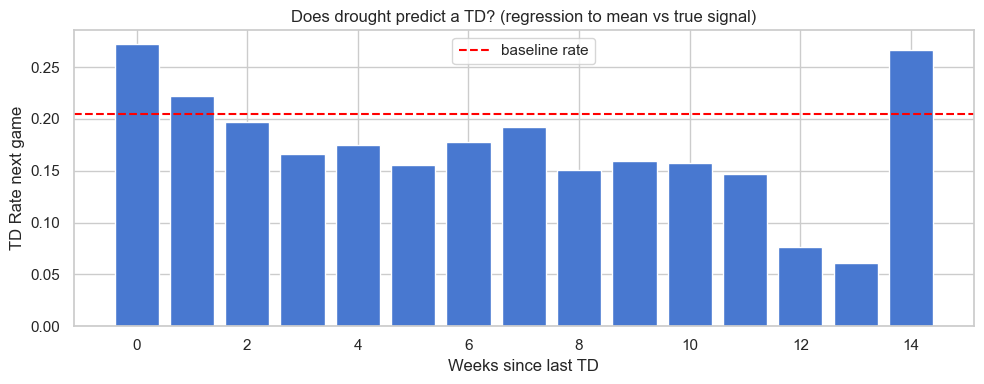

In [9]:
# Weeks since TD: does drought = due?
drought = in_season.groupby('weeks_since_td')['scored_td'].agg(['mean', 'count']).head(15)
drought.columns = ['td_rate', 'n']
print('TD rate by weeks since last TD:')
print(drought.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(drought.index, drought['td_rate'])
ax.set_xlabel('Weeks since last TD')
ax.set_ylabel('TD Rate next game')
ax.set_title('Does drought predict a TD? (regression to mean vs true signal)')
ax.axhline(in_season['scored_td'].mean(), color='red', linestyle='--', label='baseline rate')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# TD streak: does being "hot" predict another TD?
streak_rate = in_season.groupby('td_streak')['scored_td'].agg(['mean', 'count']).head(8)
streak_rate.columns = ['td_rate', 'n']
print('TD rate by current streak:')
print(streak_rate.round(3))

TD rate by current streak:
           td_rate     n
td_streak               
0            0.188  7159
1            0.256  1392
2            0.298   326
3            0.368    87
4            0.393    28
5            0.444     9
6            0.333     3
7            1.000     1


---
## 5 — Historical TD Rate (Cross-Season)

Player's overall TD rate across all available seasons — our version of 'career' given 2022–2025 window

In [11]:
# Career (data window) stats per player
career = df.groupby('player_id').agg(
    career_games=('week', 'count'),
    career_targets_pg=('targets', 'mean'),
    career_yards_pg=('rec_yards', 'mean'),
    career_td_rate=('scored_td', 'mean'),
    career_td_per_target=('rec_tds', 'sum'),
    career_total_targets=('targets', 'sum'),
).reset_index()
career['career_td_per_target'] = career['career_td_per_target'] / career['career_total_targets'].clip(lower=1)

# For a given row, historical_td_rate = career rate EXCLUDING current season
# Compute as: (career_tds - season_tds) / (career_targets - season_targets)
season_totals = df.groupby(['player_id', 'season']).agg(
    s_tds=('rec_tds', 'sum'),
    s_targets=('targets', 'sum'),
    s_games=('week', 'count')
).reset_index()

career_for_join = df[['player_id']].drop_duplicates().merge(
    df.groupby('player_id').agg(total_tds=('rec_tds','sum'), total_targets=('targets','sum'), total_games=('week','count')).reset_index(),
    on='player_id'
)

# Join season totals to each row, then compute leave-current-season-out rate
df2 = df.merge(season_totals, on=['player_id', 'season'], how='left')
df2 = df2.merge(career_for_join, on='player_id', how='left')

df2['hist_tds_excl']     = df2['total_tds'] - df2['s_tds']
df2['hist_targets_excl'] = df2['total_targets'] - df2['s_targets']
df2['hist_games_excl']   = df2['total_games'] - df2['s_games']

# Historical TD rate (other seasons) — NaN if only 1 season in window
df2['hist_td_rate'] = np.where(
    df2['hist_targets_excl'] >= 10,
    df2['hist_tds_excl'] / df2['hist_targets_excl'],
    np.nan
)
df2['hist_targets_pg'] = np.where(
    df2['hist_games_excl'] >= 5,
    df2['hist_targets_excl'] / df2['hist_games_excl'],
    np.nan
)

coverage = df2['hist_td_rate'].notna().mean()
print(f'Rows with valid hist_td_rate: {coverage:.1%}')
print()

in_s2 = df2[df2['games_played'] >= 1].copy()
corr_hist = in_s2[['hist_td_rate', 'hist_targets_pg', 'scored_td']].corr()['scored_td'].drop('scored_td')
print('Historical feature correlations with TD:')
print(corr_hist.round(3))

Rows with valid hist_td_rate: 90.6%

Historical feature correlations with TD:
hist_td_rate      0.047
hist_targets_pg   0.208
Name: scored_td, dtype: float64


---
## 6 — Target Share Within Team

Player's % of team WR+TE targets in prior weeks of season

In [12]:
# For each (team, season, week), compute cumulative team WR+TE targets up to that week
# Step 1: total cumulative team targets per player-game
team_weekly = df.groupby(['team', 'season', 'week'])['targets'].sum().reset_index()
team_weekly.columns = ['team', 'season', 'week', 'team_weekly_targets']

# Step 2: cumulative team targets up to (not including) this week
team_weekly = team_weekly.sort_values(['team', 'season', 'week'])
team_weekly['team_cum_targets'] = team_weekly.groupby(['team', 'season'])['team_weekly_targets'].cumsum().shift(1)
team_weekly['team_games'] = team_weekly.groupby(['team', 'season']).cumcount()  # 0-indexed
team_weekly['team_targets_pg'] = team_weekly['team_cum_targets'] / team_weekly['team_games'].clip(lower=1)

# Step 3: join back to player level
df3 = df.merge(team_weekly[['team', 'season', 'week', 'team_cum_targets', 'team_targets_pg']], 
               on=['team', 'season', 'week'], how='left')

# Step 4: compute share using player's own cumulative targets (same lag)
df3['target_share'] = df3['cum_targets'] / df3['team_cum_targets'].clip(lower=1)

# Also: rolling 3-game share
df3['roll3_team_targets'] = (
    df3.groupby(['team', 'season'])['targets']
    .transform(lambda x: x.rolling(3, min_periods=1).sum())
    .shift(1)
)
df3['roll3_target_share'] = (
    df3['roll3_targets'] / df3['roll3_team_targets'].clip(lower=1)
)

in_s3 = df3[df3['games_played'] >= 1].copy()
corr_share = in_s3[['target_share', 'roll3_target_share', 'team_targets_pg', 'scored_td']].corr()['scored_td'].drop('scored_td')
print('Target share correlations with TD:')
print(corr_share.round(3))
print()

# Distribution by position
print('Target share stats by position:')
print(in_s3.groupby('pos')[['target_share', 'roll3_target_share']].describe().round(3))

Target share correlations with TD:
target_share         0.175
roll3_target_share   0.029
team_targets_pg      0.016
Name: scored_td, dtype: float64

Target share stats by position:
    target_share                                           roll3_target_share  \
           count  mean   std   min   25%   50%   75%   max              count   
pos                                                                             
TE      3134.000 0.152 0.122 0.003 0.057 0.123 0.223 0.857           3134.000   
WR      5872.000 0.209 0.143 0.002 0.095 0.186 0.297 0.846           5872.000   

                                               
     mean   std   min   25%   50%   75%   max  
pos                                            
TE  0.343 0.118 0.042 0.333 0.333 0.333 1.000  
WR  0.347 0.110 0.031 0.333 0.333 0.333 2.667  


TD rate by target share quartile:
pos          TE    WR
share_q              
Q1 (low)  0.102 0.119
Q2        0.159 0.154
Q3        0.239 0.255
Q4 (high) 0.237 0.323


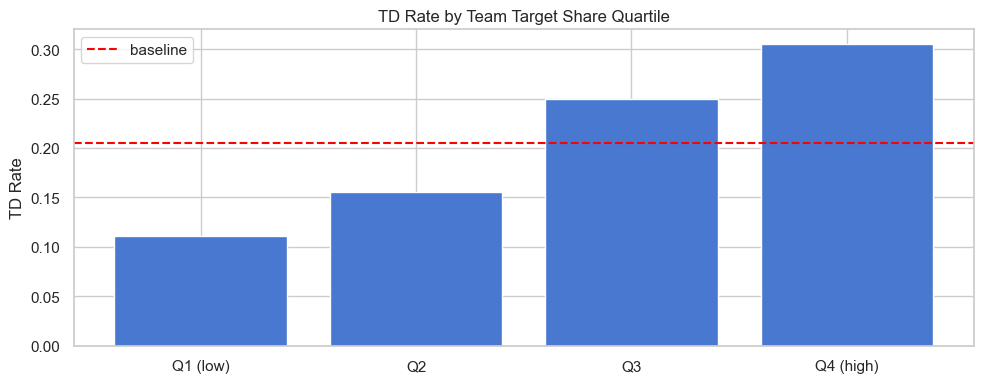

In [13]:
# Target share quartile analysis
in_s3['share_q'] = pd.qcut(in_s3['target_share'].clip(0, 1), q=4, 
                             labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'], duplicates='drop')

print('TD rate by target share quartile:')
print(in_s3.groupby(['share_q', 'pos'])['scored_td'].mean().round(3).unstack())

fig, ax = plt.subplots(figsize=(10, 4))
share_by_q = in_s3.groupby('share_q')['scored_td'].mean()
ax.bar(share_by_q.index, share_by_q.values)
ax.set_title('TD Rate by Team Target Share Quartile')
ax.set_ylabel('TD Rate')
ax.axhline(in_s3['scored_td'].mean(), color='red', linestyle='--', label='baseline')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7 — Player Profile Features

Height, experience tier, home/away

In [14]:
# Parse height from roster (e.g. '6\'3"' → inches)
def parse_height_inches(h):
    try:
        h = str(h).replace('"', '').replace("'", ' ')
        parts = h.strip().split()
        return int(parts[0]) * 12 + int(parts[1])
    except:
        return np.nan

height_map = {pid: parse_height_inches(p.get('height', '')) for pid, p in player_lookup.items()}
weight_map = {pid: float(p.get('weight', 0) or 0) for pid, p in player_lookup.items()}
exp_map    = {pid: p.get('exp', '') for pid, p in player_lookup.items()}

df['height_in'] = df['player_id'].astype(str).map(height_map)
df['weight']    = df['player_id'].astype(str).map(weight_map)

# Experience tier: R=rookie, 1-2=young, 3-6=prime, 7+=vet
def exp_tier(e):
    if str(e) in ('R', '0'):
        return 'rookie'
    try:
        yr = int(e)
        if yr <= 2: return 'young'
        if yr <= 6: return 'prime'
        return 'vet'
    except:
        return 'unknown'

df['exp_tier'] = df['player_id'].astype(str).map(exp_map).apply(exp_tier)

print('Height coverage:', df['height_in'].notna().mean().round(2))
print('Exp tier distribution:')
print(df['exp_tier'].value_counts())

Height coverage: 0.0
Exp tier distribution:
exp_tier
prime     5271
vet       3321
young      898
rookie     482
Name: count, dtype: int64


In [15]:
# Height vs TD rate — does physical profile matter?
df['height_bucket'] = pd.cut(df['height_in'], bins=[60, 71, 73, 75, 90],
                               labels=['<6ft', '6\'0-6\'1"', '6\'2-6\'3"', '6\'4+'])

print('TD rate by height (WR):')
print(df[df['pos']=='WR'].groupby('height_bucket')['scored_td'].agg(['mean', 'count']).round(3))
print()
print('TD rate by height (TE):')
print(df[df['pos']=='TE'].groupby('height_bucket')['scored_td'].agg(['mean', 'count']).round(3))

TD rate by height (WR):
Empty DataFrame
Columns: [mean, count]
Index: []

TD rate by height (TE):
Empty DataFrame
Columns: [mean, count]
Index: []


TD rate by exp tier:
          mean       count      
pos         TE    WR    TE    WR
exp_tier                        
prime    0.145 0.227  1798  3473
rookie   0.203 0.165   148   334
vet      0.194 0.222  1320  2001
young    0.150 0.188   206   692


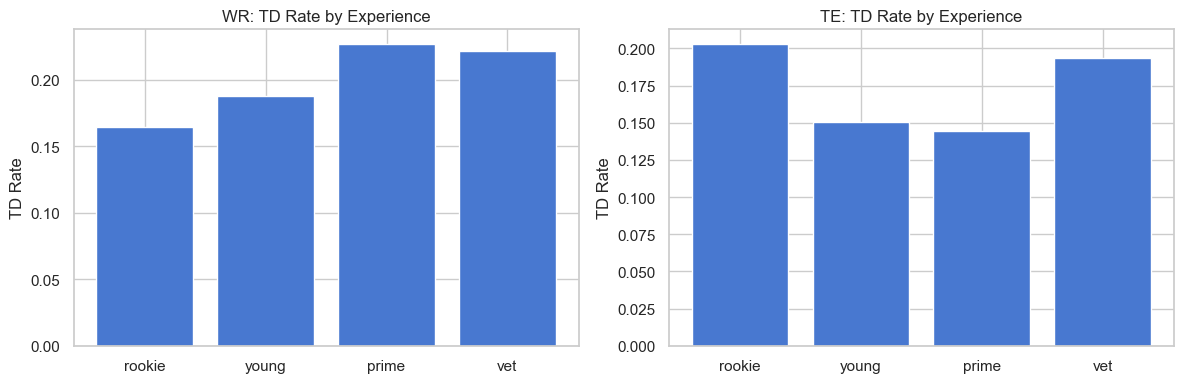

In [16]:
# Experience tier vs TD rate
print('TD rate by exp tier:')
print(df.groupby(['pos', 'exp_tier'])['scored_td'].agg(['mean', 'count']).round(3).unstack(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pos in zip(axes, ['WR', 'TE']):
    sub = df[df['pos'] == pos]
    order = ['rookie', 'young', 'prime', 'vet']
    rates = sub.groupby('exp_tier')['scored_td'].mean().reindex(order)
    ax.bar(rates.index, rates.values)
    ax.set_title(f'{pos}: TD Rate by Experience')
    ax.set_ylabel('TD Rate')
plt.tight_layout()
plt.show()

In [17]:
# Home/away from game_id format: YYYYMMDD_AWAY@HOME
def is_home(row):
    try:
        matchup = row['game_id'].split('_')[1]  # e.g. 'DAL@PHI'
        home_team = matchup.split('@')[1]
        return int(row['team'] == home_team)
    except:
        return np.nan

df['is_home'] = df.apply(is_home, axis=1)

print('Home vs away TD rate:')
print(df.groupby(['pos', 'is_home'])['scored_td'].agg(['mean', 'count']).round(3).unstack())

Home vs away TD rate:
         mean       count      
is_home     0     1     0     1
pos                            
TE      0.161 0.172  1718  1754
WR      0.207 0.229  3229  3271


---
## 8 — WR vs TE: Same Model or Separate?

Do the same features predict TDs the same way for both positions?

In [18]:
in_s_all = df[df['games_played'] >= 1].copy()

base_feats = [
    'targets_pg', 'roll3_targets', 'yards_pg', 'td_rate_per_target',
    'weeks_since_td', 'target_trend', 'lag_yards', 'lag_targets'
]

print('Feature correlations with TD — WR vs TE:')
wr_corr = in_s_all[in_s_all['pos']=='WR'][base_feats + ['scored_td']].corr()['scored_td'].drop('scored_td')
te_corr = in_s_all[in_s_all['pos']=='TE'][base_feats + ['scored_td']].corr()['scored_td'].drop('scored_td')

compare = pd.DataFrame({'WR': wr_corr, 'TE': te_corr})
compare['diff'] = (compare['WR'] - compare['TE']).abs()
print(compare.round(3).sort_values('diff', ascending=False))

Feature correlations with TD — WR vs TE:
                       WR     TE  diff
weeks_since_td     -0.098 -0.041 0.056
targets_pg          0.215  0.165 0.049
lag_targets         0.184  0.135 0.049
roll3_targets       0.212  0.167 0.045
yards_pg            0.210  0.165 0.044
lag_yards           0.170  0.130 0.040
td_rate_per_target  0.017 -0.011 0.028
target_trend        0.030  0.026 0.004


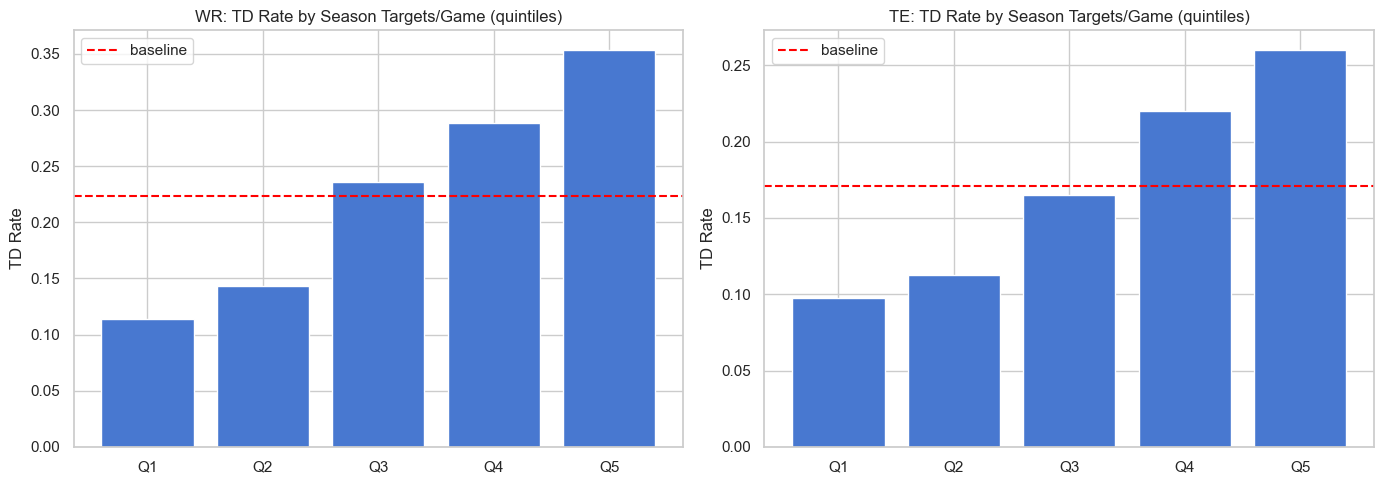

In [19]:
# Is the targets→TD relationship meaningfully different by position?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pos in zip(axes, ['WR', 'TE']):
    sub = in_s_all[in_s_all['pos'] == pos].copy()
    sub['tpg_q'] = pd.qcut(sub['targets_pg'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'], duplicates='drop')
    rates = sub.groupby('tpg_q')['scored_td'].mean()
    ax.bar(rates.index, rates.values)
    ax.set_title(f'{pos}: TD Rate by Season Targets/Game (quintiles)')
    ax.set_ylabel('TD Rate')
    ax.axhline(sub['scored_td'].mean(), color='red', linestyle='--', label='baseline')
    ax.legend()

plt.tight_layout()
plt.show()

---
## 9 — All Features Side by Side

Full correlation ranking across everything computed so far

In [20]:
# Merge all computed features into one frame for final correlation overview
all_feats = [
    # Original rolling
    'lag_yards', 'lag_targets', 'lag_receptions',
    'yards_pg', 'targets_pg', 'receptions_pg',
    'roll3_yards', 'roll3_targets', 'roll3_receptions',
    'td_rate_per_target', 'lag_ypr',
    'target_trend', 'weeks_since_td',
    # New efficiency
    'lag_catch_rate', 'roll3_catch_rate', 'season_catch_rate',
    'lag_ypt', 'season_ypt', 'roll3_long_rec',
    # Consistency
    'roll3_target_std', 'target_cv',
    # Streaks
    'td_streak', 'td_last1', 'tds_last3',
    # Profile
    'height_in', 'is_home', 'is_te', 'week',
]

in_final = df[df['games_played'] >= 1].copy()

corr_all = in_final[[f for f in all_feats if f in in_final.columns] + ['scored_td']].corr()['scored_td'].drop('scored_td').sort_values(ascending=False)

print('ALL FEATURES — correlation with scored_td (in-season):')
print(corr_all.round(3).to_string())

ALL FEATURES — correlation with scored_td (in-season):
targets_pg            0.210
roll3_targets         0.208
yards_pg              0.206
receptions_pg         0.204
roll3_receptions      0.199
roll3_yards           0.197
lag_targets           0.178
lag_yards             0.167
lag_receptions        0.166
roll3_long_rec        0.143
roll3_target_std      0.141
tds_last3             0.132
td_streak             0.091
td_last1              0.084
lag_ypr               0.060
season_ypt            0.041
lag_ypt               0.034
target_trend          0.026
is_home               0.019
lag_catch_rate        0.006
roll3_catch_rate      0.006
season_catch_rate     0.005
td_rate_per_target    0.004
week                 -0.012
target_cv            -0.023
is_te                -0.062
weeks_since_td       -0.083
height_in               NaN


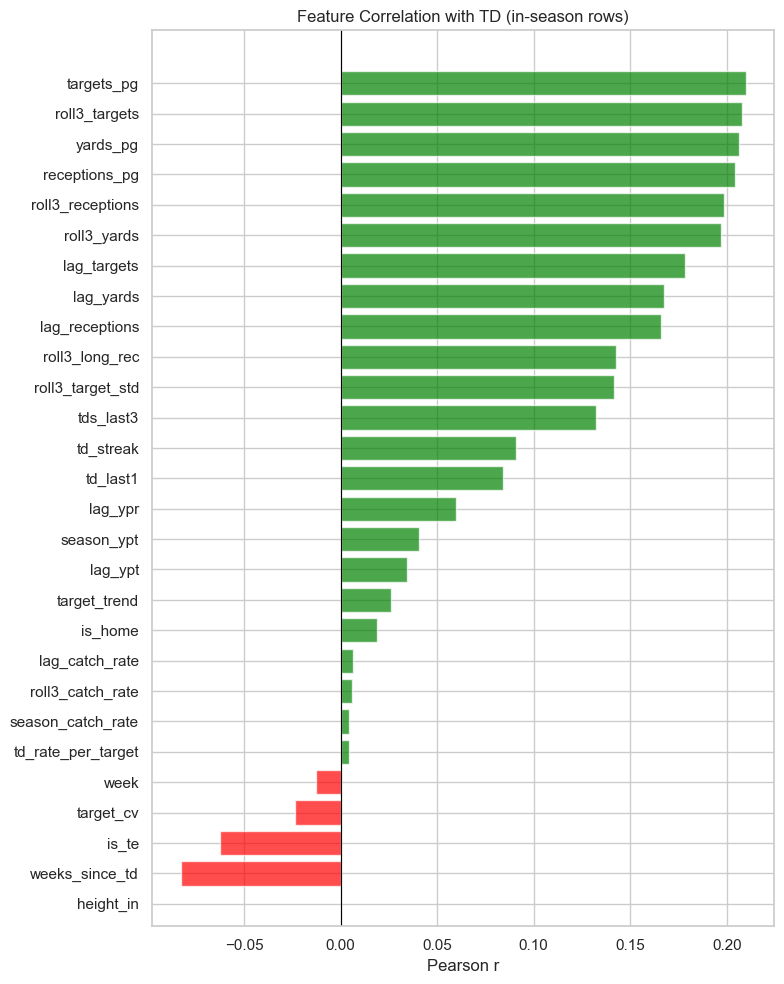

In [21]:
fig, ax = plt.subplots(figsize=(8, 10))
colors = ['green' if v > 0 else 'red' for v in corr_all.values]
ax.barh(corr_all.index, corr_all.values, color=colors, alpha=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with TD (in-season rows)')
ax.set_xlabel('Pearson r')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
# Save enriched dataset for model notebook
df.to_csv(DATA_DIR / 'game_logs_enriched.csv', index=False)
print(f'Saved enriched dataset: {df.shape}')
print('Columns:', [c for c in df.columns if c not in ['player_id', 'name', 'team', 'game_id']])

Saved enriched dataset: (9972, 57)
Columns: ['pos', 'season', 'week', 'receptions', 'targets', 'rec_yards', 'rec_tds', 'long_rec', 'rec_avg', 'scored_td', 'target_bucket', 'lag_yards', 'lag_targets', 'lag_receptions', 'cum_yards', 'cum_targets', 'cum_receptions', 'cum_tds', 'games_played', 'yards_pg', 'targets_pg', 'receptions_pg', 'roll3_yards', 'roll3_targets', 'roll3_receptions', 'td_rate_per_target', 'lag_ypr', 'target_trend', 'weeks_since_td', 'is_te', 'is_week1', 'exp', 'catch_rate_raw', 'lag_catch_rate', 'roll3_catch_rate', 'season_catch_rate', 'lag_ypt', 'season_ypt', 'roll3_long_rec', 'cr_q', 'roll3_target_std', 'target_cv', 'season_target_std', 'td_streak', 'td_last1', 'td_last2', 'td_last3', 'tds_last3', 'height_in', 'weight', 'exp_tier', 'height_bucket', 'is_home']
